In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv('heart.csv')

In [8]:
df.shape


(303, 14)

In [10]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [11]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [26]:
df['Age_Group'] = pd.qcut(
    df['age'],
    q=4,
    labels=[
        'Young',
        'Middle Age',
        'Senior',
        'Elderly'
    ]
)

/tmp/ipykernel_565/2754349266.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_target=df.groupby('Age_Group')['target'].value_counts(normalize=True).mul(100).reset_index(name='percentage')


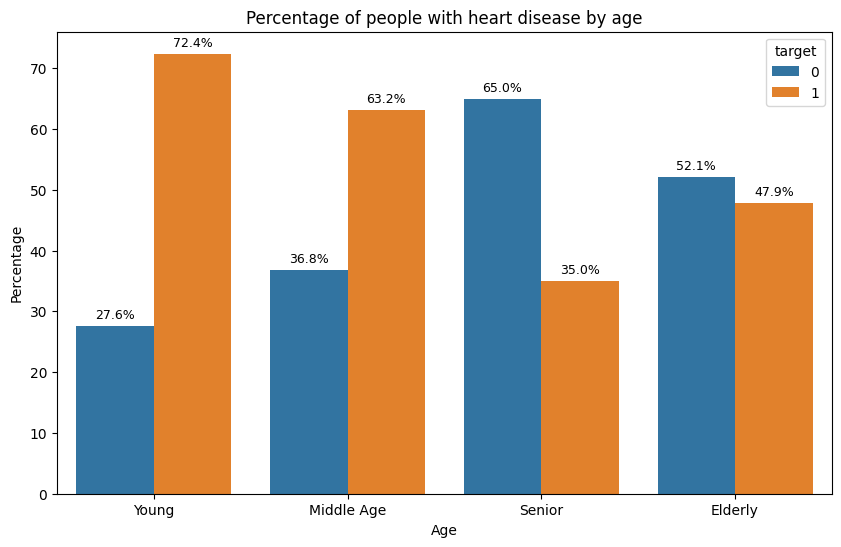

In [27]:
age_target=df.groupby('Age_Group')['target'].value_counts(normalize=True).mul(100).reset_index(name='percentage')
plt.figure(figsize=(10,6))
ax=sns.barplot(x='Age_Group',y='percentage',hue='target',data=age_target)

for container in ax.containers:
  ax.bar_label(container,fmt='%.1f%%',fontsize=9,padding=3)
plt.title('Percentage of people with heart disease by age')
plt.xlabel('Age')
plt.ylabel('Percentage')
plt.show()


/tmp/ipykernel_565/824204968.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bp=df.groupby('Age_Group')['trestbps'].mean().reset_index()


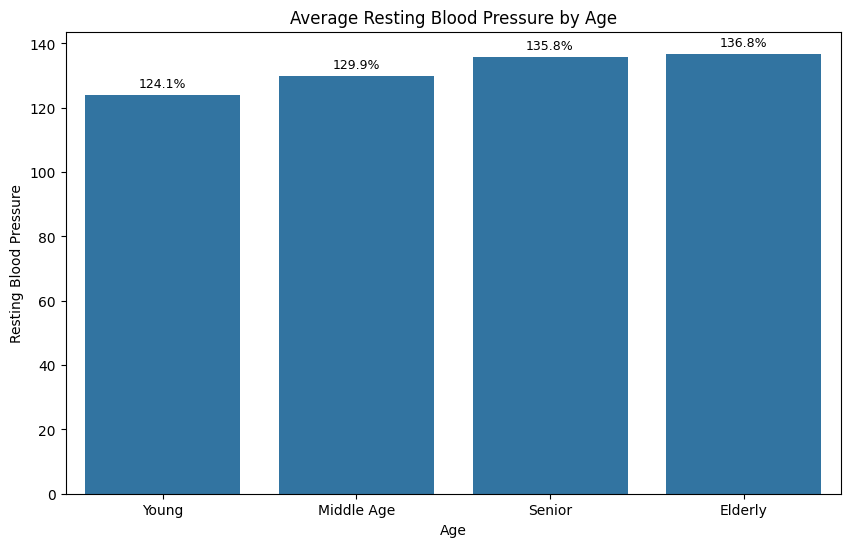

In [30]:
age_bp=df.groupby('Age_Group')['trestbps'].mean().reset_index()
plt.figure(figsize=(10,6))
ax=sns.barplot(x='Age_Group',y='trestbps',data=age_bp)
for container in ax.containers:
  ax.bar_label(container,fmt='%.1f%%',fontsize=9,padding=3)
plt.title('Average Resting Blood Pressure by Age')
plt.xlabel('Age')
plt.ylabel('Resting Blood Pressure')
plt.show()

## 💡 Insight 1: Age Group vs Heart Disease

The analysis shows that the **Young** and **Middle Age** groups recorded the highest proportion of patients with heart disease in this dataset, while the **Senior** and **Elderly** groups exhibited comparatively lower percentages. This indicates that, within the sampled population, heart disease was not limited to older individuals and was also prevalent among younger patients.

Supporting analysis revealed that the **average resting blood pressure increased steadily with age**, rising from approximately **124 mmHg** in the Young group to nearly **137 mmHg** in the Elderly group. This suggests that although blood pressure tends to increase with age, it alone does not explain the distribution of heart disease observed in this dataset, highlighting the importance of considering multiple clinical risk factors during diagnosis.

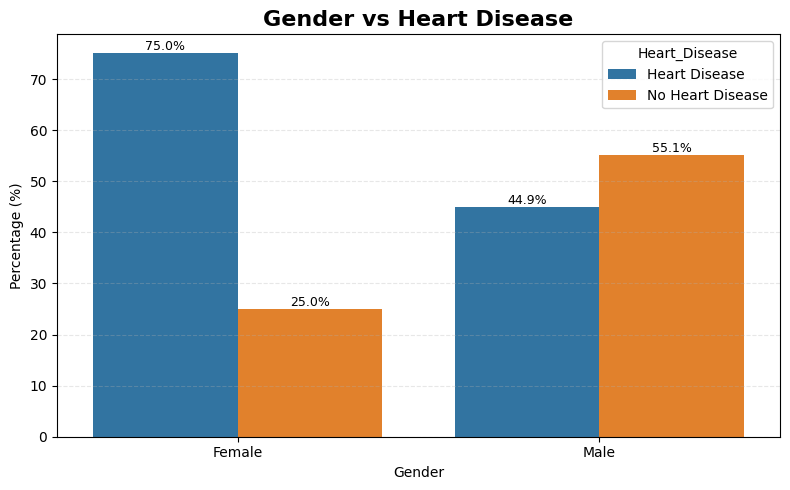

In [31]:
sex_target = (
    df.groupby('sex')['target']
      .value_counts(normalize=True)
      .mul(100)
      .reset_index(name='Percentage')
)

sex_target['Heart_Disease'] = sex_target['target'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=sex_target,
    x='sex',
    y='Percentage',
    hue='Heart_Disease'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title(
    'Gender vs Heart Disease',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Gender')
plt.ylabel('Percentage (%)')

plt.xticks([0,1],['Female','Male'])

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

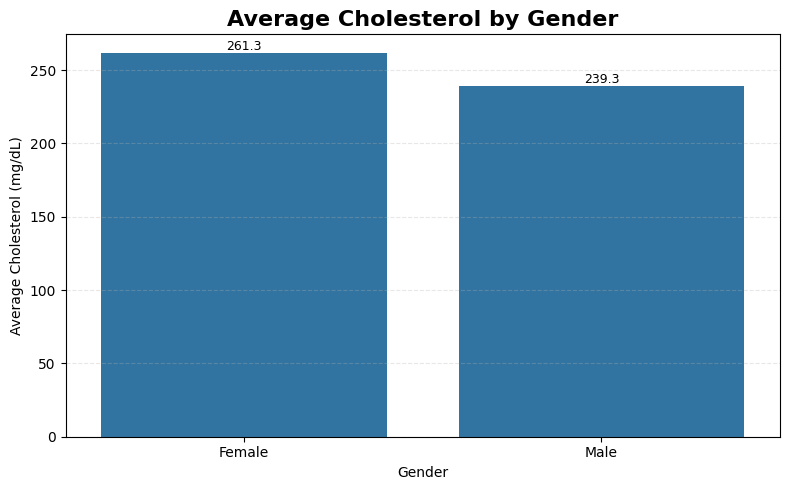

In [32]:
sex_chol = (
    df.groupby('sex')['chol']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=sex_chol,
    x='sex',
    y='chol'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.title(
    'Average Cholesterol by Gender',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Gender')
plt.ylabel('Average Cholesterol (mg/dL)')

plt.xticks([0,1],['Female','Male'])

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 2: Gender vs Heart Disease

The analysis indicates that **female patients** recorded a higher proportion of heart disease cases compared to male patients within this dataset. This finding differs from common population-level observations, suggesting that the sampled data may not fully represent the general population.

Supporting analysis showed that **female patients also exhibited a higher average cholesterol level (261.3 mg/dL)** compared to **male patients (239.3 mg/dL)**. Since elevated cholesterol is a recognized cardiovascular risk factor, this relationship may partially explain the higher prevalence of heart disease observed among female patients in this dataset. However, the result should be interpreted cautiously because of the limited sample size and dataset-specific characteristics.

In [33]:
df['Chest_Pain_Type'] = df['cp'].map({
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-Anginal Pain',
    3: 'Asymptomatic'
})

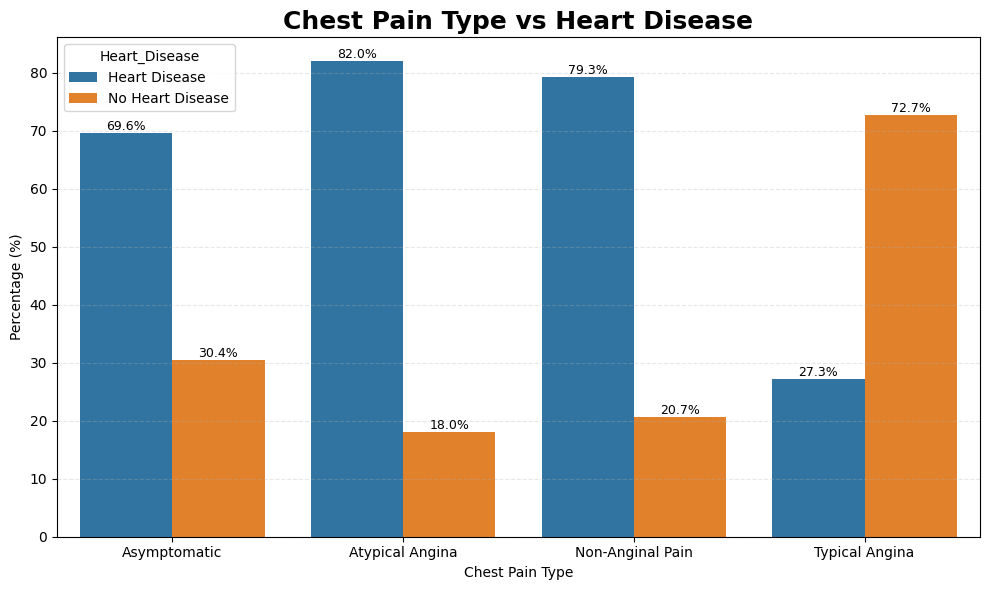

In [34]:
cp_target = (
    df.groupby('Chest_Pain_Type')['target']
      .value_counts(normalize=True)
      .mul(100)
      .reset_index(name='Percentage')
)

cp_target['Heart_Disease'] = cp_target['target'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=cp_target,
    x='Chest_Pain_Type',
    y='Percentage',
    hue='Heart_Disease'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title(
    'Chest Pain Type vs Heart Disease',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Chest Pain Type')
plt.ylabel('Percentage (%)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

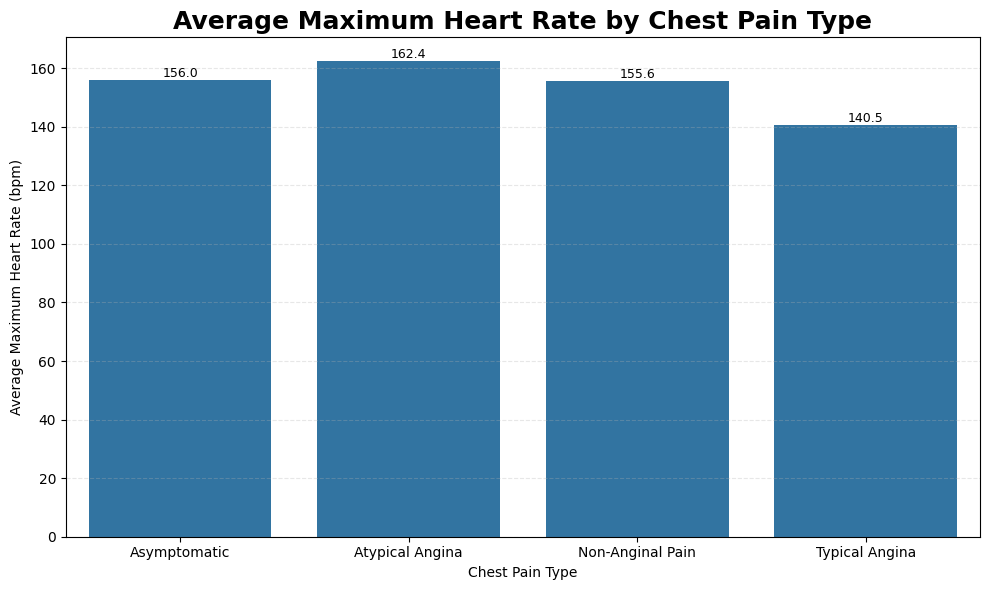

In [35]:
cp_hr = (
    df.groupby('Chest_Pain_Type')['thalach']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=cp_hr,
    x='Chest_Pain_Type',
    y='thalach'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.title(
    'Average Maximum Heart Rate by Chest Pain Type',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Chest Pain Type')
plt.ylabel('Average Maximum Heart Rate (bpm)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## 💡 Insight 3: Chest Pain Type vs Heart Disease

The analysis reveals that **Atypical Angina (82.0%)** and **Non-Anginal Pain (79.3%)** recorded the highest proportion of heart disease cases in this dataset, followed by **Asymptomatic (69.6%)** patients. In contrast, patients with **Typical Angina** exhibited the lowest prevalence of heart disease (27.3%), with the majority showing no evidence of heart disease.

Supporting analysis showed that patients with **Typical Angina** also had the **lowest average maximum heart rate (140.5 bpm)**, whereas **Atypical Angina** patients recorded the **highest average maximum heart rate (162.4 bpm)**. This suggests that different chest pain presentations are associated with distinct cardiovascular responses and highlights chest pain type as an important clinical indicator during heart disease assessment.

In [36]:
df['Cholesterol_Group'] = pd.cut(
    df['chol'],
    bins=[0, 200, 240, 600],
    labels=[
        'Normal (<200)',
        'Borderline (200-240)',
        'High (>240)'
    ]
)

/tmp/ipykernel_565/3904295216.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Cholesterol_Group')['target']


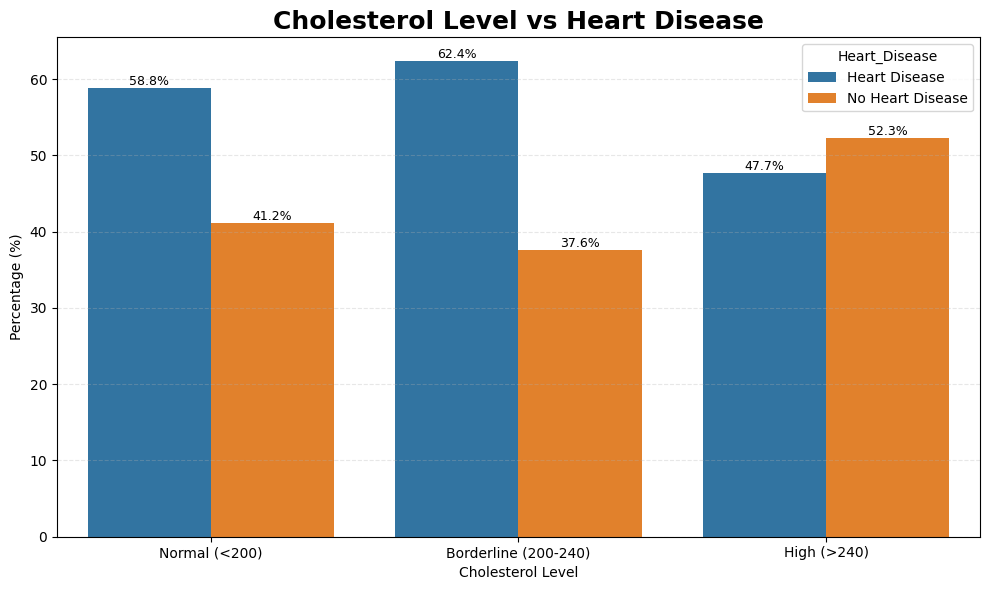

In [37]:
chol_target = (
    df.groupby('Cholesterol_Group')['target']
      .value_counts(normalize=True)
      .mul(100)
      .reset_index(name='Percentage')
)

chol_target['Heart_Disease'] = chol_target['target'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=chol_target,
    x='Cholesterol_Group',
    y='Percentage',
    hue='Heart_Disease'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title(
    'Cholesterol Level vs Heart Disease',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Cholesterol Level')
plt.ylabel('Percentage (%)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_565/722753585.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['chol']


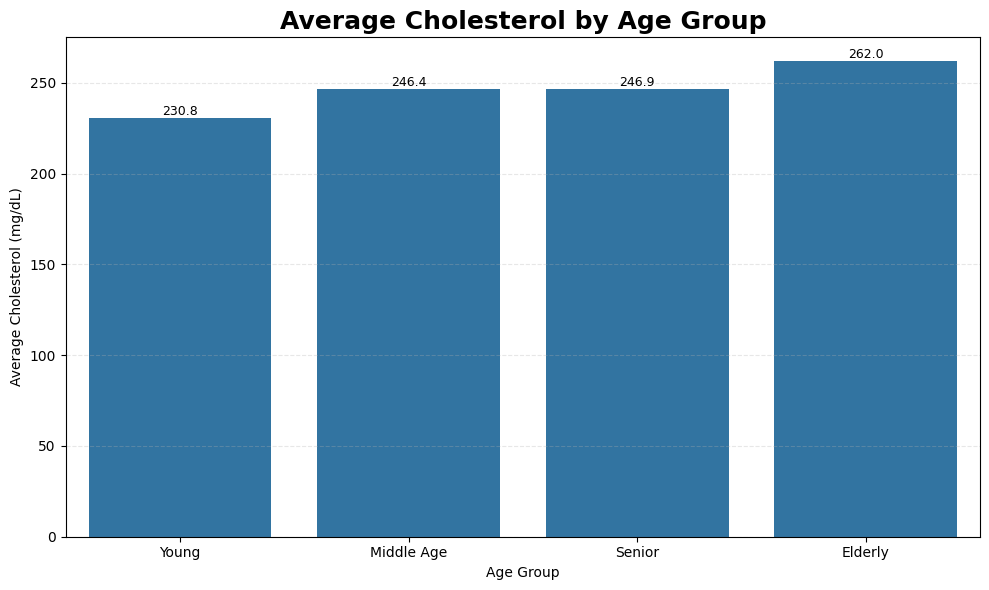

In [38]:
age_chol = (
    df.groupby('Age_Group')['chol']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=age_chol,
    x='Age_Group',
    y='chol'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.title(
    'Average Cholesterol by Age Group',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Age Group')
plt.ylabel('Average Cholesterol (mg/dL)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 💡 Insight 4: Cholesterol Level vs Heart Disease

The analysis indicates that patients with **Borderline Cholesterol (200–240 mg/dL)** exhibited the highest proportion of heart disease cases (62.4%), followed by patients with **Normal Cholesterol (58.8%)**. Interestingly, patients classified under the **High Cholesterol (>240 mg/dL)** group recorded the lowest proportion of heart disease (47.7%) within this dataset, which differs from the commonly observed medical trend.

Supporting analysis showed that the **average cholesterol level increased progressively with age**, rising from **230.8 mg/dL** in the Young group to **262.0 mg/dL** among Elderly patients. This indicates that cholesterol generally increases with age; however, cholesterol alone does not fully explain the occurrence of heart disease in this dataset. Other clinical factors such as chest pain type, blood pressure, exercise-induced angina, and ECG findings should also be considered during cardiovascular risk assessment.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                303 non-null    int64   
 1   sex                303 non-null    int64   
 2   cp                 303 non-null    int64   
 3   trestbps           303 non-null    int64   
 4   chol               303 non-null    int64   
 5   fbs                303 non-null    int64   
 6   restecg            303 non-null    int64   
 7   thalach            303 non-null    int64   
 8   exang              303 non-null    int64   
 9   oldpeak            303 non-null    float64 
 10  slope              303 non-null    int64   
 11  ca                 303 non-null    int64   
 12  thal               303 non-null    int64   
 13  target             303 non-null    int64   
 14  Age_Group          303 non-null    category
 15  Chest_Pain_Type    303 non-null    object  
 16  Choleste

In [41]:
df['Oldpeak_Group'] = pd.cut(
    df['oldpeak'],
    bins=[-0.1, 1, 2, 4, 7],
    labels=[
        'Low (0-1)',
        'Moderate (1-2)',
        'High (2-4)',
        'Very High (>4)'
    ]
)

/tmp/ipykernel_565/865798821.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Oldpeak_Group')['target']


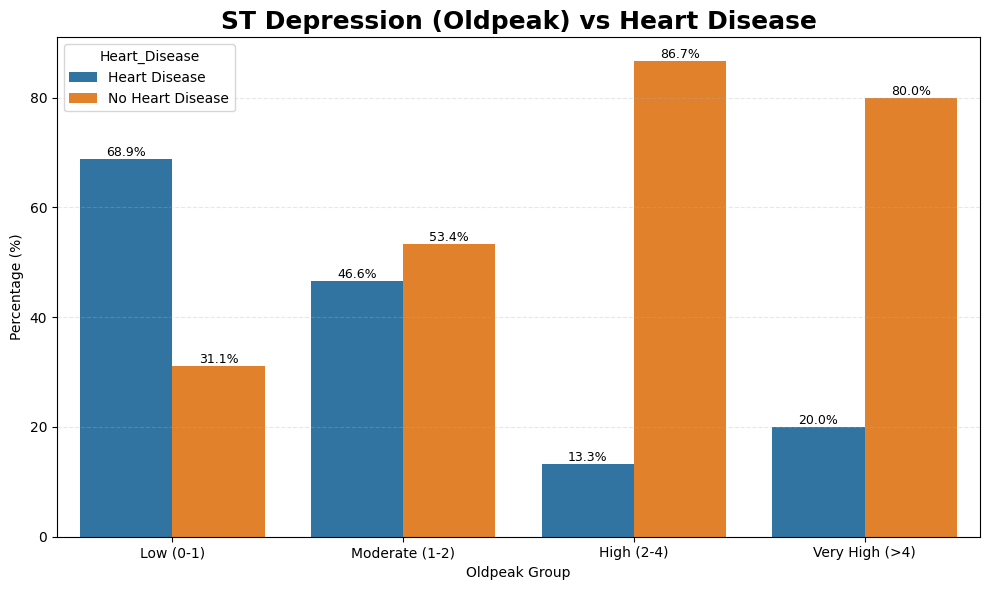

In [43]:
oldpeak_target = (
    df.groupby('Oldpeak_Group')['target']
      .value_counts(normalize=True)
      .mul(100)
      .reset_index(name='Percentage')
)

oldpeak_target['Heart_Disease'] = oldpeak_target['target'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=oldpeak_target,
    x='Oldpeak_Group',
    y='Percentage',
    hue='Heart_Disease'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title(
    'ST Depression (Oldpeak) vs Heart Disease',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Oldpeak Group')
plt.ylabel('Percentage (%)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_565/2522780586.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Oldpeak_Group')['thalach']


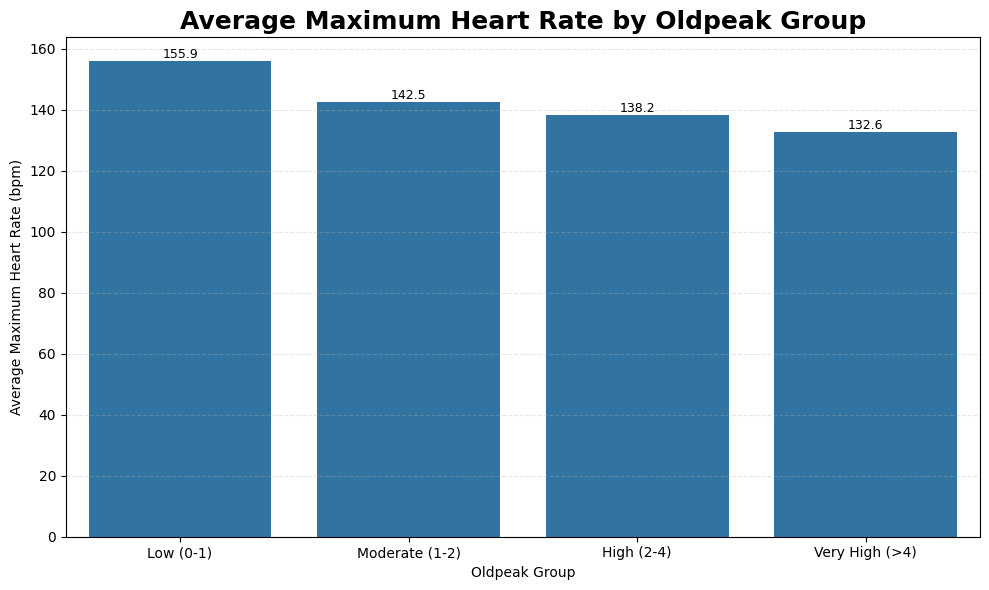

In [44]:
oldpeak_hr = (
    df.groupby('Oldpeak_Group')['thalach']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=oldpeak_hr,
    x='Oldpeak_Group',
    y='thalach'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.title(
    'Average Maximum Heart Rate by Oldpeak Group',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Oldpeak Group')
plt.ylabel('Average Maximum Heart Rate (bpm)')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

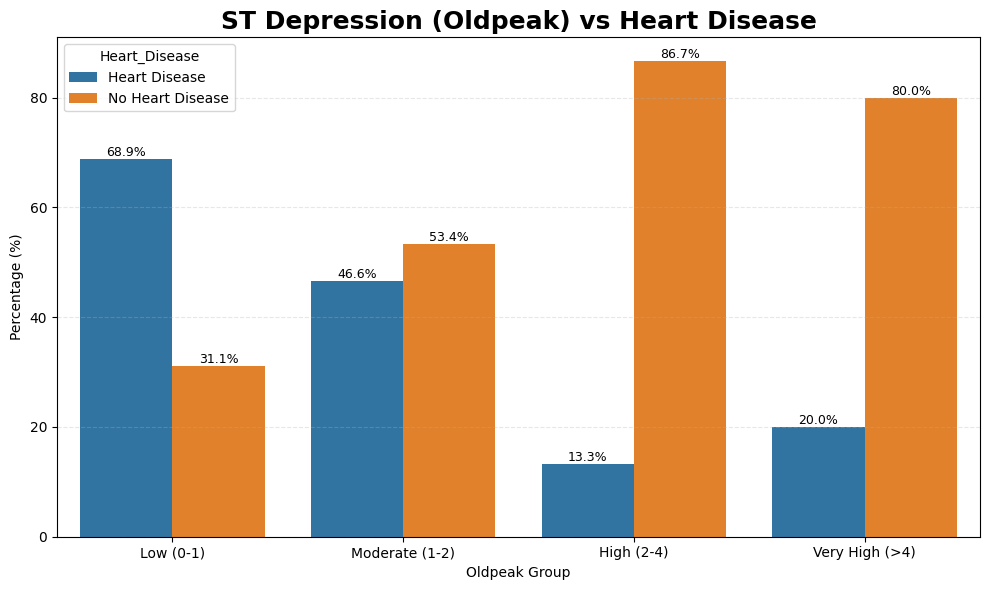

## 💡 Insight 5: ST Depression (Oldpeak) vs Heart Disease

The analysis indicates that patients in the **Low Oldpeak (0–1)** group recorded the highest proportion of heart disease cases (68.9%) in this dataset, while patients in the **High (2–4)** and **Very High (>4)** Oldpeak groups exhibited comparatively lower percentages of heart disease. Although this finding differs from the commonly observed clinical trend, it reflects the characteristics of the sampled dataset.

Supporting analysis revealed a clear decline in the **average maximum heart rate** as Oldpeak increased, decreasing from **155.9 bpm** in the Low Oldpeak group to **132.6 bpm** in the Very High Oldpeak group. This suggests that patients with greater ST-segment depression generally demonstrated lower exercise capacity, highlighting the importance of interpreting ECG findings alongside other clinical indicators during cardiovascular assessment.

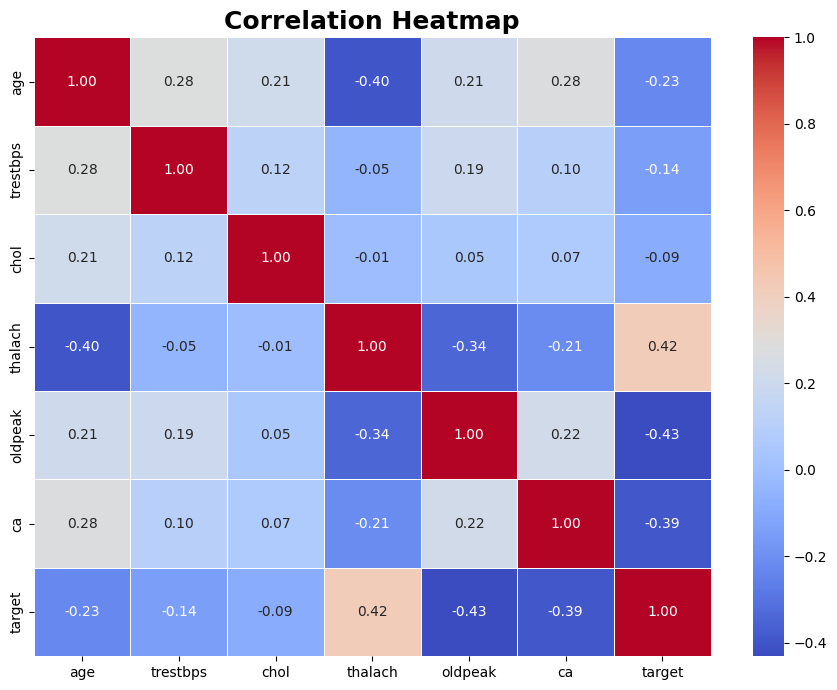

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[
    [
        'age',
        'trestbps',
        'chol',
        'thalach',
        'oldpeak',
        'ca',
        'target'
    ]
].corr()

plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

## 📊 Correlation Heatmap

The correlation heatmap was used to examine the relationships among the numerical clinical variables in the dataset. It highlights how patient age, resting blood pressure, cholesterol level, maximum heart rate, ST depression (Oldpeak), and the number of major vessels are associated with one another and with the presence of heart disease.

The analysis indicates that **Maximum Heart Rate (thalach)** and **Oldpeak** exhibit relatively stronger relationships with heart disease compared to several other clinical measurements. The heatmap also shows that no single variable alone perfectly explains heart disease occurrence, emphasizing that cardiovascular diagnosis relies on evaluating multiple clinical factors together rather than a single measurement.

# 📝 Conclusion

This exploratory analysis examined the major demographic and clinical factors associated with heart disease using a patient dataset of 303 individuals. The study focused on understanding how age, gender, chest pain type, cholesterol, ST depression, and other cardiovascular indicators relate to heart disease occurrence.

The analysis revealed that **Chest Pain Type**, **Maximum Heart Rate**, and **ST Depression (Oldpeak)** provided some of the most clinically meaningful insights within this dataset. Supporting analyses further demonstrated how exercise capacity and physiological measurements varied across different patient groups.

Several findings, including those related to **Age**, **Gender**, and **Cholesterol**, differed from commonly reported medical trends. These differences are likely influenced by the relatively small sample size and the specific characteristics of the dataset. Therefore, the insights should be interpreted as observations specific to this dataset rather than generalized conclusions about the broader population.

Overall, the analysis demonstrates that **heart disease assessment requires consideration of multiple clinical indicators rather than relying on a single risk factor**, highlighting the complexity of cardiovascular diagnosis and the importance of comprehensive patient evaluation.